In [282]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
path = "df_final.csv"
df_final = pd.read_csv(path)
df_final

,Zone,Cereales/Milliers_tonnes,Année,Animaux/Milliers_tonnes,Vegetaux/Milliers_tonnes,population_millions,Soualimentation/million
0,Afghanistan,6350,2013,2280.0,8891.0,30.552,7.9
1,Afrique du Sud,14155,2013,7614.0,55649.0,52.776,2.6
2,Albanie,703,2013,1355.0,2609.0,3.173,0.2
3,Algérie,4914,2013,4395.0,21964.0,39.208,1.7
4,Allemagne,47757,2013,43621.0,110926.0,82.727,NaN
...,...,...,...,...,...,...,...
162,Émirats arabes unis,55,2013,412.0,780.0,9.346,0.4
163,Équateur,2598,2013,4295.0,20042.0,15.738,1.3
164,États-Unis d'Amérique,433686,2013,154474.0,740194.0,320.051,NaN
165,Éthiopie,22646,2013,5195.0,40907.0,94.101,25.3


In [283]:
df_kmeans = df_final.copy()

In [284]:
df_final.columns

Index(['Zone', 'Cereales/Milliers_tonnes', 'Année', 'Animaux/Milliers_tonnes',
       'Vegetaux/Milliers_tonnes', 'population_millions',
       'Soualimentation/million'],
      dtype='object')

In [285]:
df_final["Soualimentation/million"] = pd.to_numeric(
    df_final["Soualimentation/million"], errors="coerce"
)



In [286]:
#separation les données, en 2 bases, une avec des valeurs manquantes et l'autre avec les valeurs, pour entrainer le model et qu'il trouve les valeurs à mettre dans la base où les valeurs sont manquantes
df_complet= df_final[df_final["Soualimentation/million"].notna()]
df_manqu = df_final[df_final["Soualimentation/million"].isna()]

In [287]:
df_complet

,Zone,Cereales/Milliers_tonnes,Année,Animaux/Milliers_tonnes,Vegetaux/Milliers_tonnes,population_millions,Soualimentation/million
0,Afghanistan,6350,2013,2280.0,8891.0,30.552,7.9
1,Afrique du Sud,14155,2013,7614.0,55649.0,52.776,2.6
2,Albanie,703,2013,1355.0,2609.0,3.173,0.2
3,Algérie,4914,2013,4395.0,21964.0,39.208,1.7
5,Angola,1663,2013,764.0,28093.0,21.472,8.1
...,...,...,...,...,...,...,...
160,Zimbabwe,1011,2013,740.0,7174.0,14.150,6.6
161,Égypte,22217,2013,9849.0,85999.0,82.056,3.9
162,Émirats arabes unis,55,2013,412.0,780.0,9.346,0.4
163,Équateur,2598,2013,4295.0,20042.0,15.738,1.3


In [288]:
df_manqu

,Zone,Cereales/Milliers_tonnes,Année,Animaux/Milliers_tonnes,Vegetaux/Milliers_tonnes,population_millions,Soualimentation/million
4,Allemagne,47757,2013,43621.0,110926.0,82.727,NaN
6,Antigua-et-Barbuda,0,2013,9.0,11.0,0.090,NaN
10,Australie,35212,2013,15685.0,85271.0,23.343,NaN
11,Autriche,4873,2013,4781.0,13348.0,8.495,NaN
12,Azerbaïdjan,2906,2013,2235.0,7539.0,9.413,NaN
...,...,...,...,...,...,...,...
153,Ukraine,62638,2013,15653.0,133654.0,45.239,NaN
154,Uruguay,3594,2013,3382.0,8205.0,3.407,NaN
155,Vanuatu,1,2013,71.0,688.0,0.253,NaN
164,États-Unis d'Amérique,433686,2013,154474.0,740194.0,320.051,NaN


In [289]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# 1) Séparer les données complètes
X_complet = df_complet.drop(columns=['Zone','Soualimentation/million','Année'])
y_complet = df_complet["Soualimentation/million"]

# 2) Split train/test pour évaluer le modèle
X_train, X_test, y_train, y_test = train_test_split(
    X_complet, y_complet, test_size=0.2, random_state=42
)

# 3) Entraîner le modèle
model = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)
model.fit(X_train, y_train)

# 4) Prédictions train et test
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# 5) Scores R²
print("R2 train :", r2_score(y_train, y_pred_train))
print("R2 test  :", r2_score(y_test, y_pred_test))

# 6) RMSE (compatible toutes versions sklearn)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("RMSE train :", rmse_train)
print("RMSE test  :", rmse_test)

# 7) Prédire les valeurs manquantes
X_manqu = df_manqu.drop(columns=['Zone','Soualimentation/million','Année'])
y_manque_pred = model.predict(X_manqu)

# 8) Remplir df_manqu avec les valeurs prédites
df_manqu_filled = df_manqu.copy()
df_manqu_filled["Soualimentation/million"] = y_manque_pred

# 9) Reconstituer un DataFrame final complet
#df_final = pd.concat([df_complet, df_manqu_filled], ignore_index=True)
df_final.loc[df_final["Soualimentation/million"].isna(),
             "Soualimentation/million"] = y_manque_pred

print("\nValeurs manquantes imputées :")
print(y_manque_pred)

print("\nDataFrame final complet :")
df_final


R2 train : 0.835636987188965
R2 test  : 0.9559137295436793
RMSE train : 10.063383207685947
RMSE test  : 6.270331522016949

Valeurs manquantes imputées :
[  6.934    0.27     2.3774   0.6294   0.7532   0.27     0.2764   1.235
   0.3942   0.2636   0.27    48.9504   0.6532   0.2806   4.6782   0.7762
   0.3092   0.7252   2.5558   0.4494   0.27     4.4092   0.295    0.4376
   0.4474   7.018   15.8822   0.27     1.3906   0.3356   0.663    0.6306
   0.6782   4.8768  15.7336   1.8258   0.3858   0.3084   0.231    0.3264
   0.298    0.3034   0.2984   0.4346   0.307    0.4512   0.2744   0.5816
   1.6904   4.3594   1.3372   2.1122   5.5958   8.0054   0.3616   0.2762
   0.27     0.27     0.3308   0.7162   0.3132   0.6586   0.9314   1.3198
   0.3042   6.7052   5.752    0.2514   0.3092 101.5208   0.2992]

DataFrame final complet :


,Zone,Cereales/Milliers_tonnes,Année,Animaux/Milliers_tonnes,Vegetaux/Milliers_tonnes,population_millions,Soualimentation/million
0,Afghanistan,6350,2013,2280.0,8891.0,30.552,7.9000
1,Afrique du Sud,14155,2013,7614.0,55649.0,52.776,2.6000
2,Albanie,703,2013,1355.0,2609.0,3.173,0.2000
3,Algérie,4914,2013,4395.0,21964.0,39.208,1.7000
4,Allemagne,47757,2013,43621.0,110926.0,82.727,6.9340
...,...,...,...,...,...,...,...
162,Émirats arabes unis,55,2013,412.0,780.0,9.346,0.4000
163,Équateur,2598,2013,4295.0,20042.0,15.738,1.3000
164,États-Unis d'Amérique,433686,2013,154474.0,740194.0,320.051,101.5208
165,Éthiopie,22646,2013,5195.0,40907.0,94.101,25.3000


In [290]:
df_final

,Zone,Cereales/Milliers_tonnes,Année,Animaux/Milliers_tonnes,Vegetaux/Milliers_tonnes,population_millions,Soualimentation/million
0,Afghanistan,6350,2013,2280.0,8891.0,30.552,7.9000
1,Afrique du Sud,14155,2013,7614.0,55649.0,52.776,2.6000
2,Albanie,703,2013,1355.0,2609.0,3.173,0.2000
3,Algérie,4914,2013,4395.0,21964.0,39.208,1.7000
4,Allemagne,47757,2013,43621.0,110926.0,82.727,6.9340
...,...,...,...,...,...,...,...
162,Émirats arabes unis,55,2013,412.0,780.0,9.346,0.4000
163,Équateur,2598,2013,4295.0,20042.0,15.738,1.3000
164,États-Unis d'Amérique,433686,2013,154474.0,740194.0,320.051,101.5208
165,Éthiopie,22646,2013,5195.0,40907.0,94.101,25.3000


In [291]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Zone                      167 non-null    object 
 1   Cereales/Milliers_tonnes  167 non-null    int64  
 2   Année                     167 non-null    int64  
 3   Animaux/Milliers_tonnes   167 non-null    float64
 4   Vegetaux/Milliers_tonnes  167 non-null    float64
 5   population_millions       167 non-null    float64
 6   Soualimentation/million   167 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 9.3+ KB


In [292]:
df_final.isnull().sum()

Zone                        0
Cereales/Milliers_tonnes    0
Année                       0
Animaux/Milliers_tonnes     0
Vegetaux/Milliers_tonnes    0
population_millions         0
Soualimentation/million     0
dtype: int64

In [293]:
from sklearn.preprocessing import StandardScaler
#il faut choisir uniquement les colonne numérique sinon ça ne fonctionne pas 

X_indicateurs = df_final.select_dtypes(include="number")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_indicateurs)

In [294]:
X_scaled.shape

(167, 6)

C:\Users\abboud\AppData\Local\Temp\ipykernel_22596\143273867.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
C:\Users\abboud\AppData\Local\Temp\ipykernel_22596\143273867.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


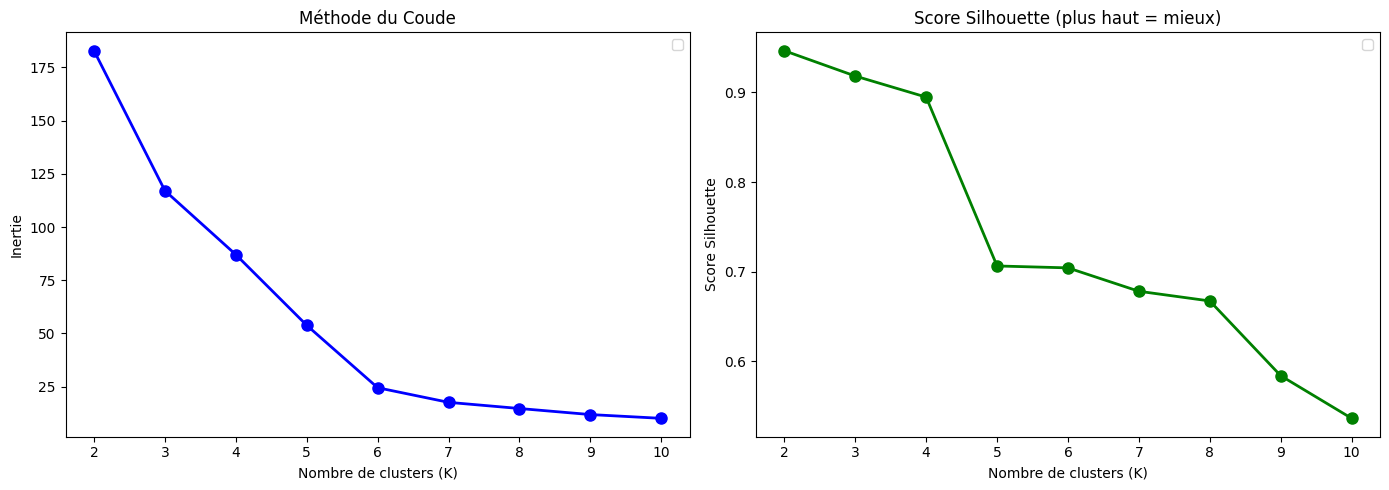


Meilleur K selon silhouette : 2


In [295]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inerties = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coude (Inertie)
axes[0].plot(K_range, inerties, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Nombre de clusters (K)')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Méthode du Coude')
axes[0].legend()

# Silhouette
axes[1].plot(K_range, silhouettes, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Nombre de clusters (K)')
axes[1].set_ylabel('Score Silhouette')
axes[1].set_title('Score Silhouette (plus haut = mieux)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nMeilleur K selon silhouette : {list(K_range)[silhouettes.index(max(silhouettes))]}")


In [296]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

df_final["cluster"] = labels


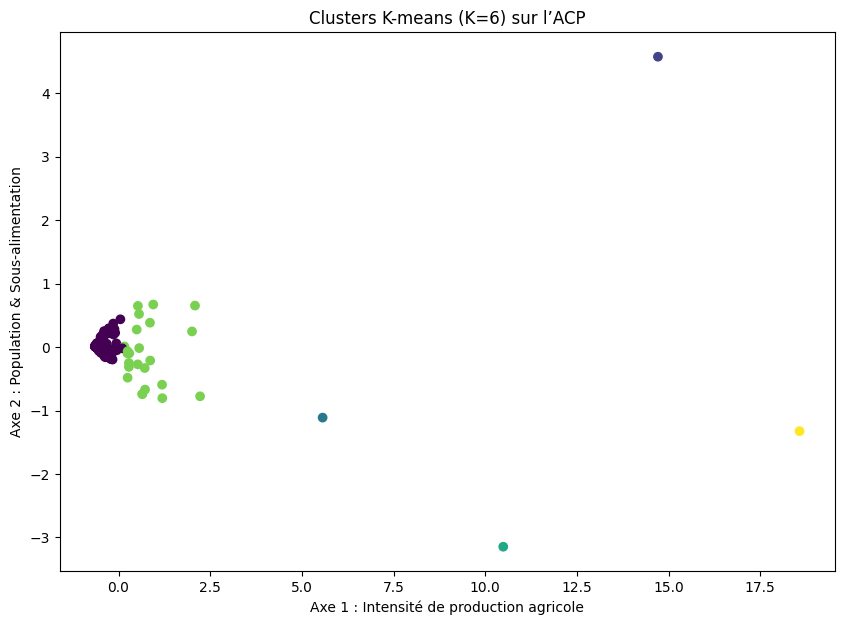

In [297]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
composantes = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,7))
plt.scatter(composantes[:,0], composantes[:,1], c=labels, cmap="viridis")
plt.xlabel("Axe 1 : Intensité de production agricole")
plt.ylabel("Axe 2 : Population & Sous-alimentation")
plt.title("Clusters K-means (K=6) sur l’ACP")
plt.show()



In [298]:
for c in range(6):
    print(f"\nCluster {c} :")
    print(df_final[df_final["cluster"] == c]["Zone"].tolist())



Cluster 0 :
['Afghanistan', 'Afrique du Sud', 'Albanie', 'Algérie', 'Angola', 'Antigua-et-Barbuda', 'Arabie saoudite', 'Arménie', 'Autriche', 'Azerbaïdjan', 'Bahamas', 'Barbade', 'Belgique', 'Belize', 'Bolivie (État plurinational de)', 'Bosnie-Herzégovine', 'Botswana', 'Brunéi Darussalam', 'Bulgarie', 'Burkina Faso', 'Bélarus', 'Bénin', 'Cabo Verde', 'Cambodge', 'Cameroun', 'Chili', 'Chine - RAS de Hong-Kong', 'Chine, Taiwan Province de', 'Chypre', 'Colombie', 'Congo', 'Costa Rica', 'Croatie', 'Cuba', "Côte d'Ivoire", 'Danemark', 'Djibouti', 'Dominique', 'El Salvador', 'Estonie', 'Eswatini', 'Fidji', 'Finlande', 'Gabon', 'Gambie', 'Ghana', 'Grenade', 'Grèce', 'Guatemala', 'Guinée', 'Guinée-Bissau', 'Guyana', 'Géorgie', 'Haïti', 'Honduras', 'Hongrie', 'Iraq', 'Irlande', 'Israël', 'Jamaïque', 'Jordanie', 'Kazakhstan', 'Kenya', 'Kirghizistan', 'Koweït', 'Lesotho', 'Lettonie', 'Liban', 'Libéria', 'Lituanie', 'Luxembourg', 'Macédoine du Nord', 'Madagascar', 'Malaisie', 'Malawi', 'Maldives'

In [299]:
profils = {}

for c in range(6):
    data_c = df_final[df_final["cluster"] == c]
    
    profil = {
        "nb_pays": len(data_c),
        "soualimentation_moy": data_c["Soualimentation/million"].mean(),
        "production_totale_moy": (
            data_c["Cereales/Milliers_tonnes"] +
            data_c["Animaux/Milliers_tonnes"] +
            data_c["Vegetaux/Milliers_tonnes"]
        ).mean(),
        "population_moy": data_c["population_millions"].mean()
    }
    
    profils[c] = profil

    noms_clusters = {}

prod_median = np.median([profils[i]["production_totale_moy"] for i in profils])

for c, p in profils.items():
    
    if p["soualimentation_moy"] == 0 and p["production_totale_moy"] > prod_median:
        nom = "Pays très productifs et autosuffisants"
    
    elif p["soualimentation_moy"] == 0 and p["production_totale_moy"] <= prod_median:
        nom = "Pays stables à faible production"
    
    elif p["soualimentation_moy"] > 0 and p["production_totale_moy"] < prod_median:
        nom = "Pays vulnérables en insécurité alimentaire"
    
    else:
        nom = "Pays agricoles sous-performants"
    
    noms_clusters[c] = nom

df_final["cluster_nom"] = df_final["cluster"].map(noms_clusters)


#Afficher les pays par cluster avec leur nom
for c in range(6):
    print(f"\nCluster {c} — {noms_clusters[c]}")
    print(df_final[df_final["cluster"] == c]["Zone"].tolist())




Cluster 0 — Pays vulnérables en insécurité alimentaire
['Afghanistan', 'Afrique du Sud', 'Albanie', 'Algérie', 'Angola', 'Antigua-et-Barbuda', 'Arabie saoudite', 'Arménie', 'Autriche', 'Azerbaïdjan', 'Bahamas', 'Barbade', 'Belgique', 'Belize', 'Bolivie (État plurinational de)', 'Bosnie-Herzégovine', 'Botswana', 'Brunéi Darussalam', 'Bulgarie', 'Burkina Faso', 'Bélarus', 'Bénin', 'Cabo Verde', 'Cambodge', 'Cameroun', 'Chili', 'Chine - RAS de Hong-Kong', 'Chine, Taiwan Province de', 'Chypre', 'Colombie', 'Congo', 'Costa Rica', 'Croatie', 'Cuba', "Côte d'Ivoire", 'Danemark', 'Djibouti', 'Dominique', 'El Salvador', 'Estonie', 'Eswatini', 'Fidji', 'Finlande', 'Gabon', 'Gambie', 'Ghana', 'Grenade', 'Grèce', 'Guatemala', 'Guinée', 'Guinée-Bissau', 'Guyana', 'Géorgie', 'Haïti', 'Honduras', 'Hongrie', 'Iraq', 'Irlande', 'Israël', 'Jamaïque', 'Jordanie', 'Kazakhstan', 'Kenya', 'Kirghizistan', 'Koweït', 'Lesotho', 'Lettonie', 'Liban', 'Libéria', 'Lituanie', 'Luxembourg', 'Macédoine du Nord', 'Ma

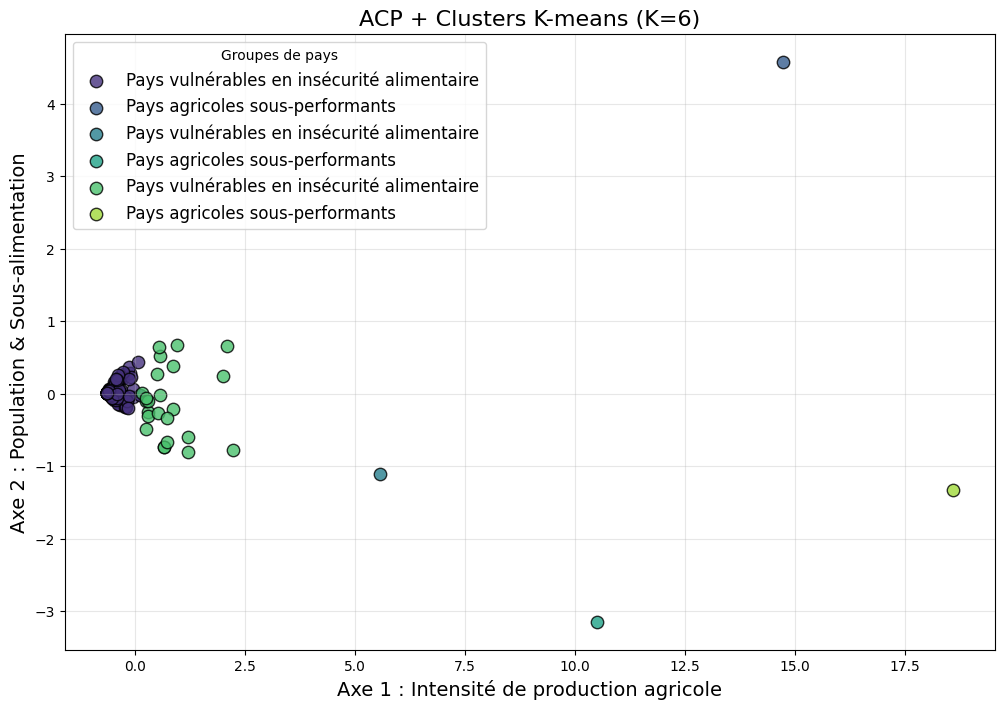

In [300]:
plt.figure(figsize=(12,8))
palette = sns.color_palette("viridis", 6)

for c in range(6):
    plt.scatter(
        composantes[df_final["cluster"] == c, 0],
        composantes[df_final["cluster"] == c, 1],
        s=80,
        color=palette[c],
        label=noms_clusters[c],
        alpha=0.8,
        edgecolor="black"
    )

plt.xlabel("Axe 1 : Intensité de production agricole", fontsize=14)
plt.ylabel("Axe 2 : Population & Sous-alimentation", fontsize=14)
plt.title("ACP + Clusters K-means (K=6)", fontsize=16)
plt.legend(title="Groupes de pays", fontsize=12)
plt.grid(alpha=0.3)
plt.show()


###une copie de la base de données finale qui prends les valeur manquantes et les concidère comme des pays sans sousalimentation 

In [301]:
df_kmeans 

,Zone,Cereales/Milliers_tonnes,Année,Animaux/Milliers_tonnes,Vegetaux/Milliers_tonnes,population_millions,Soualimentation/million
0,Afghanistan,6350,2013,2280.0,8891.0,30.552,7.9
1,Afrique du Sud,14155,2013,7614.0,55649.0,52.776,2.6
2,Albanie,703,2013,1355.0,2609.0,3.173,0.2
3,Algérie,4914,2013,4395.0,21964.0,39.208,1.7
4,Allemagne,47757,2013,43621.0,110926.0,82.727,NaN
...,...,...,...,...,...,...,...
162,Émirats arabes unis,55,2013,412.0,780.0,9.346,0.4
163,Équateur,2598,2013,4295.0,20042.0,15.738,1.3
164,États-Unis d'Amérique,433686,2013,154474.0,740194.0,320.051,NaN
165,Éthiopie,22646,2013,5195.0,40907.0,94.101,25.3


In [302]:
# Remplacer les valeurs manquantes par 0
df_kmeans["Soualimentation/million"] = df_kmeans["Soualimentation/million"].fillna(0)
#Sélectionner les colonnes numériques pour K‑means
X = df_kmeans.select_dtypes(include="number")
#Standardiser les données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

df_kmeans["cluster"] = labels


In [303]:
col_cer = "Cereales/Milliers_tonnes"
col_anim = "Animaux/Milliers_tonnes"
col_veg = "Vegetaux/Milliers_tonnes"
col_pop = "population_millions"
col_soual = "Soualimentation/million"


In [304]:

df_kmeans[col_soual] = df_kmeans[col_soual].fillna(0)
X = df_kmeans[[col_cer, col_anim, col_veg, col_pop, col_soual]] #uniquement les valeure numérique

#normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

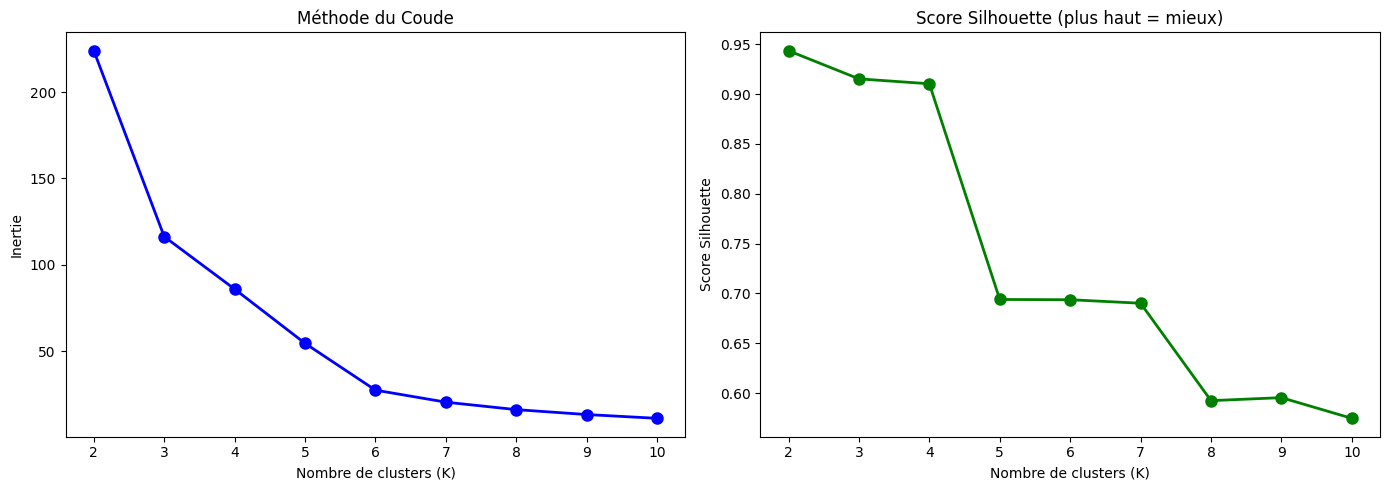


Meilleur K selon silhouette : 2


In [305]:
inerties = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Méthode du coude
axes[0].plot(K_range, inerties, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Nombre de clusters (K)')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Méthode du Coude')

# Score silhouette
axes[1].plot(K_range, silhouettes, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Nombre de clusters (K)')
axes[1].set_ylabel('Score Silhouette')
axes[1].set_title('Score Silhouette (plus haut = mieux)')

plt.tight_layout()
plt.show()

# Affichage du meilleur K selon silhouette
best_k = list(K_range)[silhouettes.index(max(silhouettes))]
print(f"\nMeilleur K selon silhouette : {best_k}")

In [306]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
labels2 = kmeans.fit_predict(X_scaled)
df_kmeans["cluster"] = labels2
pca = PCA(n_components=2)
composantes = pca.fit_transform(X_scaled)


In [307]:
import numpy as np
range(3)
 
profils = {}

for c in range(6):
    data_c = df_final[df_final["cluster"] == c]
    
    profil = {
        "nb_pays": len(data_c),
        "soualimentation_moy": data_c[col_soual].mean(),
        "production_totale_moy": (
            data_c[col_cer] + data_c[col_anim] + data_c[col_veg]
        ).mean(),
        "population_moy": data_c[col_pop].mean()
    }
    
    profils[c] = profil

In [308]:
#Nommer automatiquement les clusters
noms_clusters = {}

prod_median = np.median([profils[i]["production_totale_moy"] for i in profils])

for c, p in profils.items():
    
    if p["soualimentation_moy"] == 0 and p["production_totale_moy"] > prod_median:
        nom = "Pays très productifs et autosuffisants"
    
    elif p["soualimentation_moy"] == 0 and p["production_totale_moy"] <= prod_median:
        nom = "Pays stables à faible production"
    
    elif p["soualimentation_moy"] > 0 and p["production_totale_moy"] < prod_median:
        nom = "Pays vulnérables en insécurité alimentaire"
    
    else:
        nom = "Pays agricoles sous-performants"
    
    noms_clusters[c] = nom

df_final["cluster_nom"] = df_final["cluster"].map(noms_clusters)



In [309]:
#Afficher les pays par cluster
for c in range(6):
    print(f"\nCluster {c} — {noms_clusters[c]}")
    print(df_final[df_final["cluster"] == c]["Zone"].tolist())




Cluster 0 — Pays vulnérables en insécurité alimentaire
['Afghanistan', 'Afrique du Sud', 'Albanie', 'Algérie', 'Angola', 'Antigua-et-Barbuda', 'Arabie saoudite', 'Arménie', 'Autriche', 'Azerbaïdjan', 'Bahamas', 'Barbade', 'Belgique', 'Belize', 'Bolivie (État plurinational de)', 'Bosnie-Herzégovine', 'Botswana', 'Brunéi Darussalam', 'Bulgarie', 'Burkina Faso', 'Bélarus', 'Bénin', 'Cabo Verde', 'Cambodge', 'Cameroun', 'Chili', 'Chine - RAS de Hong-Kong', 'Chine, Taiwan Province de', 'Chypre', 'Colombie', 'Congo', 'Costa Rica', 'Croatie', 'Cuba', "Côte d'Ivoire", 'Danemark', 'Djibouti', 'Dominique', 'El Salvador', 'Estonie', 'Eswatini', 'Fidji', 'Finlande', 'Gabon', 'Gambie', 'Ghana', 'Grenade', 'Grèce', 'Guatemala', 'Guinée', 'Guinée-Bissau', 'Guyana', 'Géorgie', 'Haïti', 'Honduras', 'Hongrie', 'Iraq', 'Irlande', 'Israël', 'Jamaïque', 'Jordanie', 'Kazakhstan', 'Kenya', 'Kirghizistan', 'Koweït', 'Lesotho', 'Lettonie', 'Liban', 'Libéria', 'Lituanie', 'Luxembourg', 'Macédoine du Nord', 'Ma

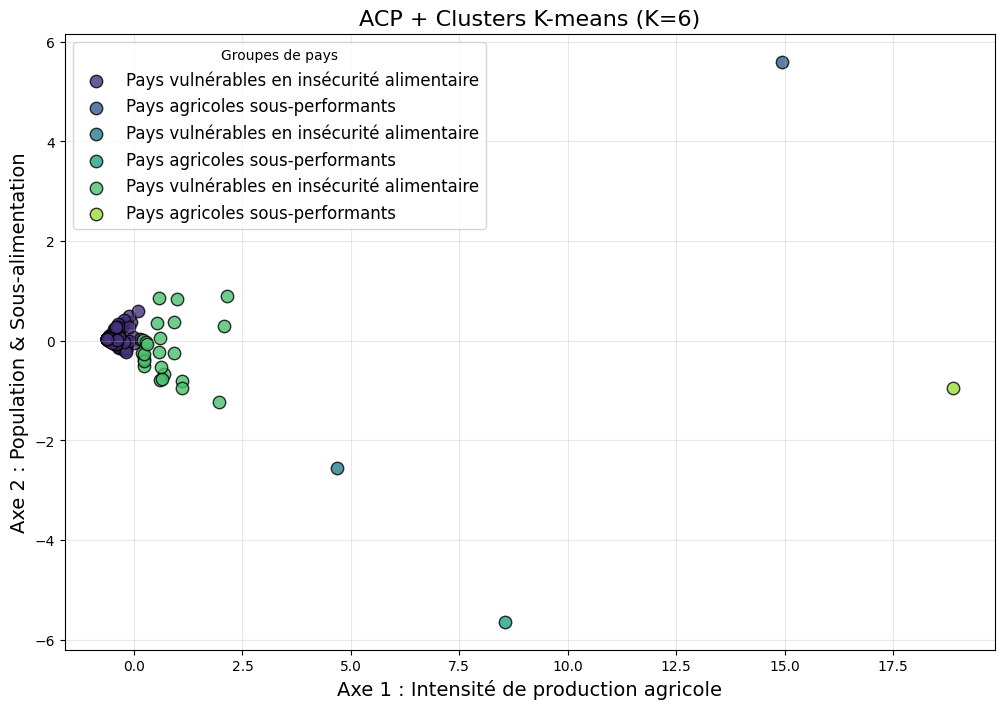

In [310]:
plt.figure(figsize=(12,8))
palette = sns.color_palette("viridis", 6)

for c in range(6):
    plt.scatter(
        composantes[df_final["cluster"] == c, 0],
        composantes[df_final["cluster"] == c, 1],
        s=80,
        color=palette[c],
        label=noms_clusters[c],
        alpha=0.8,
        edgecolor="black"
    )

plt.xlabel("Axe 1 : Intensité de production agricole", fontsize=14)
plt.ylabel("Axe 2 : Population & Sous-alimentation", fontsize=14)
plt.title("ACP + Clusters K-means (K=6)", fontsize=16)
plt.legend(title="Groupes de pays", fontsize=12)
plt.grid(alpha=0.3)
plt.show()


In [311]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
labels6 = kmeans.fit_predict(X_scaled)

df_kmeans["cluster"] = labels6


In [312]:
col_cer = "Cereales/Milliers_tonnes"
col_anim = "Animaux/Milliers_tonnes"
col_veg = "Vegetaux/Milliers_tonnes"
col_pop = "population_millions"
col_soual = "Soualimentation/million"

X = df_final[[col_cer, col_anim, col_veg, col_pop, col_soual]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [313]:
#Profils détaillés pour les 6 clusters


profils = {}

for c in range(6):
    data_c2 = df_kmeans[df_kmeans["cluster"] == c]
    
    profil = {
        "nb_pays": len(data_c),

        "soualimentation_moy": data_c2[col_soual].mean(),
        "soualimentation_med": data_c2[col_soual].median(),

        "cereales_moy": data_c2[col_cer].mean(),
        "animaux_moy": data_c2[col_anim].mean(),
        "vegetaux_moy": data_c2[col_veg].mean(),

        "cereales_med": data_c2[col_cer].median(),
        "animaux_med": data_c2[col_anim].median(),
        "vegetaux_med": data_c2[col_veg].median(),

        "population_moy": data_c2[col_pop].mean(),
        "population_med": data_c2[col_pop].median(),

        "production_totale_moy": (data_c2[col_cer] + data_c2[col_anim] + data_c2[col_veg]).mean(),
        "production_totale_med": (data_c2[col_cer] + data_c2[col_anim] + data_c2[col_veg]).median(),
    }
    
    profils[c] = profil


Nommer automatiquement les 6 clusters

In [314]:
noms_clusters = {}

prod_median = np.median([profils[i]["production_totale_moy"] for i in profils])

for c, p in profils.items():
    
    if p["soualimentation_moy"] == 0 and p["production_totale_moy"] > prod_median:
        nom = "Pays très productifs et autosuffisants"
    
    elif p["soualimentation_moy"] == 0 and p["production_totale_moy"] <= prod_median:
        nom = "Pays stables à faible production"
    
    elif p["soualimentation_moy"] > 0 and p["production_totale_moy"] < prod_median:
        nom = "Pays vulnérables en insécurité alimentaire"
    
    else:
        nom = "Pays agricoles sous-performants"
    
    noms_clusters[c] = nom

df_kmeans["cluster_nom"] = df_kmeans["cluster"].map(noms_clusters)


In [315]:
for c in range(6):
    print(f"\nCluster {c} — {noms_clusters[c]}")
    print(df_kmeans[df_kmeans["cluster"] == c]["Zone"].tolist())




Cluster 0 — Pays vulnérables en insécurité alimentaire
['Afghanistan', 'Afrique du Sud', 'Albanie', 'Algérie', 'Angola', 'Antigua-et-Barbuda', 'Arabie saoudite', 'Arménie', 'Autriche', 'Azerbaïdjan', 'Bahamas', 'Barbade', 'Belgique', 'Belize', 'Bolivie (État plurinational de)', 'Bosnie-Herzégovine', 'Botswana', 'Brunéi Darussalam', 'Bulgarie', 'Burkina Faso', 'Bélarus', 'Bénin', 'Cabo Verde', 'Cambodge', 'Cameroun', 'Chili', 'Chine - RAS de Hong-Kong', 'Chine, Taiwan Province de', 'Chypre', 'Colombie', 'Congo', 'Costa Rica', 'Croatie', 'Cuba', "Côte d'Ivoire", 'Danemark', 'Djibouti', 'Dominique', 'El Salvador', 'Estonie', 'Eswatini', 'Fidji', 'Finlande', 'Gabon', 'Gambie', 'Ghana', 'Grenade', 'Grèce', 'Guatemala', 'Guinée', 'Guinée-Bissau', 'Guyana', 'Géorgie', 'Haïti', 'Honduras', 'Hongrie', 'Iraq', 'Irlande', 'Israël', 'Jamaïque', 'Jordanie', 'Kazakhstan', 'Kenya', 'Kirghizistan', 'Koweït', 'Lesotho', 'Lettonie', 'Liban', 'Libéria', 'Lituanie', 'Luxembourg', 'Macédoine du Nord', 'Ma

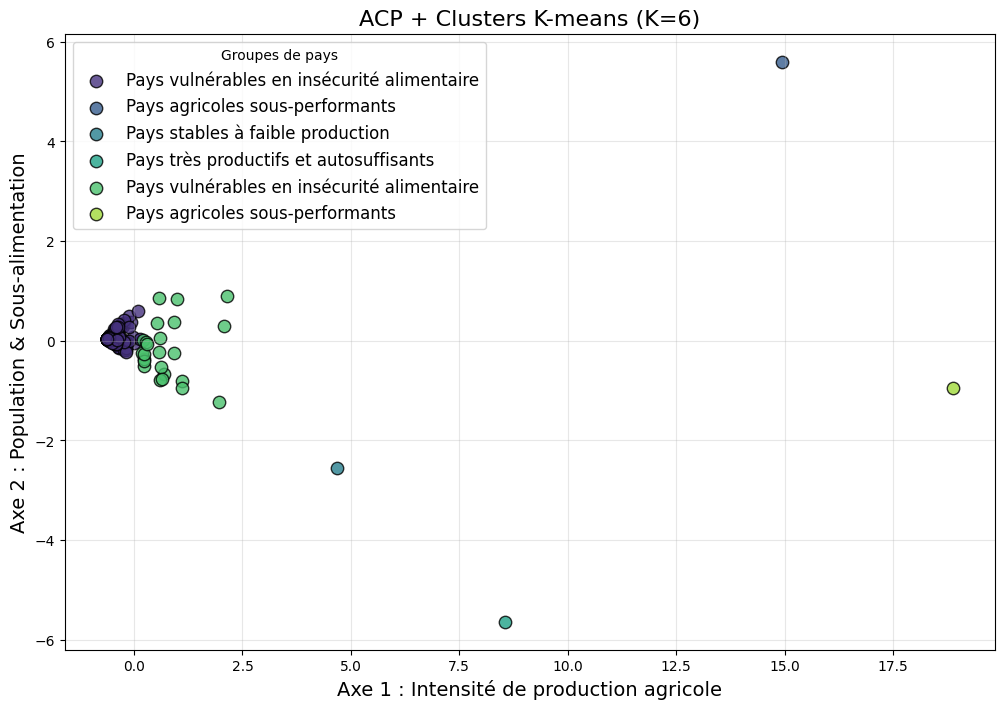

In [316]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

palette = sns.color_palette("viridis", 6)

for c in range(6):
    plt.scatter(
        composantes[df_kmeans["cluster"] == c, 0],
        composantes[df_kmeans["cluster"] == c, 1],
        s=80,
        color=palette[c],
        label=noms_clusters[c],
        alpha=0.8,
        edgecolor="black"
    )

plt.xlabel("Axe 1 : Intensité de production agricole", fontsize=14)
plt.ylabel("Axe 2 : Population & Sous-alimentation", fontsize=14)

plt.title("ACP + Clusters K-means (K=6)", fontsize=16)
plt.legend(title="Groupes de pays", fontsize=12)
plt.grid(alpha=0.3)

plt.show()


In [317]:
from sklearn.cluster import KMeans

kmeans4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels4 = kmeans4.fit_predict(X_scaled)

df_kmeans["cluster"] = labels4

In [318]:
import numpy as np

profils4 = {}

for c in range(4):
    data_c = df_kmeans[df_kmeans["cluster"] == c]
    profil = {
        "nb_pays": len(data_c),
        "soualimentation_moy": data_c[col_soual].mean(),
        "production_totale_moy": (data_c[col_cer] + data_c[col_anim] + data_c[col_veg]).mean(),
        "population_moy": data_c[col_pop].mean()
    }
    profils4[c] = profil

# Définition automatique des noms
noms_clusters = {}
prod_median = np.median([profils4[i]["production_totale_moy"] for i in profils4])

for c, p in profils4.items():
    if p["soualimentation_moy"] == 0 and p["production_totale_moy"] > prod_median:
        nom = "Pays très productifs et autosuffisants"
    elif p["soualimentation_moy"] == 0 and p["production_totale_moy"] <= prod_median:
        nom = "Pays stables à faible production"
    elif p["soualimentation_moy"] > 0 and p["production_totale_moy"] < prod_median:
        nom = "Pays vulnérables en insécurité alimentaire"
    else:
        nom = "Pays agricoles sous-performants"

    noms_clusters[c] = nom

df_kmeans["cluster_nom"] = df_kmeans["cluster"].map(noms_clusters)


In [319]:
for c in range(4):
    print(f"\nCluster {c} - {noms_clusters[c]}")
    print(df_kmeans[df_kmeans["cluster"] == c]["Zone"].tolist())



Cluster 0 - Pays vulnérables en insécurité alimentaire
['Afghanistan', 'Afrique du Sud', 'Albanie', 'Algérie', 'Allemagne', 'Angola', 'Antigua-et-Barbuda', 'Arabie saoudite', 'Argentine', 'Arménie', 'Australie', 'Autriche', 'Azerbaïdjan', 'Bahamas', 'Bangladesh', 'Barbade', 'Belgique', 'Belize', 'Bolivie (État plurinational de)', 'Bosnie-Herzégovine', 'Botswana', 'Brunéi Darussalam', 'Bulgarie', 'Burkina Faso', 'Bélarus', 'Bénin', 'Cabo Verde', 'Cambodge', 'Cameroun', 'Canada', 'Chili', 'Chine - RAS de Hong-Kong', 'Chine, Taiwan Province de', 'Chypre', 'Colombie', 'Congo', 'Costa Rica', 'Croatie', 'Cuba', "Côte d'Ivoire", 'Danemark', 'Djibouti', 'Dominique', 'El Salvador', 'Espagne', 'Estonie', 'Eswatini', 'Fidji', 'Finlande', 'France', 'Fédération de Russie', 'Gabon', 'Gambie', 'Ghana', 'Grenade', 'Grèce', 'Guatemala', 'Guinée', 'Guinée-Bissau', 'Guyana', 'Géorgie', 'Haïti', 'Honduras', 'Hongrie', 'Indonésie', "Iran (République islamique d')", 'Iraq', 'Irlande', 'Israël', 'Italie', '

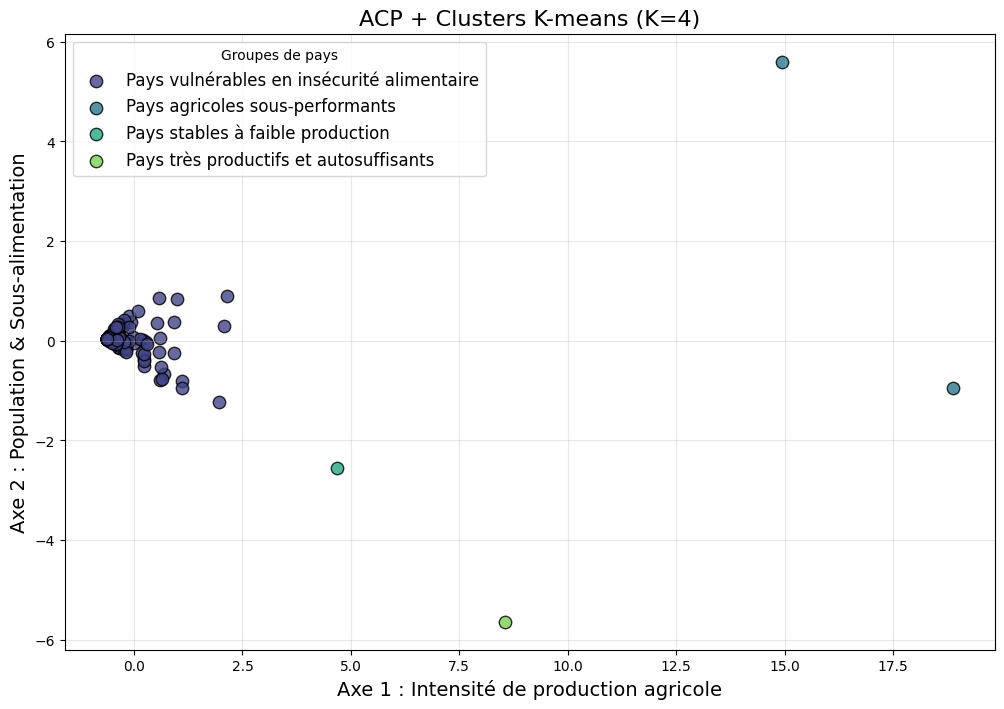

In [320]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

palette = sns.color_palette("viridis", 4)

for c in range(4):
    plt.scatter(
        composantes[df_kmeans["cluster"] == c, 0],
        composantes[df_kmeans["cluster"] == c, 1],
        s=80,
        color=palette[c],
        label=noms_clusters[c],
        alpha=0.8,
        edgecolor="black"
    )

plt.xlabel("Axe 1 : Intensité de production agricole", fontsize=14)
plt.ylabel("Axe 2 : Population & Sous-alimentation", fontsize=14)

plt.title("ACP + Clusters K-means (K=4)", fontsize=16)
plt.legend(title="Groupes de pays", fontsize=12)
plt.grid(alpha=0.3)

plt.show()


In [323]:
 #pip install sweetviz (à executer dans le terminal pour l'installer )
import sweetviz as sv
report_kmeans= sv.analyze(df_kmeans)
report_kmeans.show_html()

                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
